# Introduction to Business Analytics

## Lecture 3 - Classification

So, it's time to learn about Classification models. This notebook will run you through the essential concepts, and give examples on how to run multiple Classification algorithms.


As always, let's do some imports. 

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score
%matplotlib inline

-----

## Part 1 - Logistic Regression

_The first model of the lecture relates with Logistic Regression. It is important that you understand the mechanics well, because their are applicable in other types of Classification models_

We want you to understand the intuition behind the logit function, so let's work on the basics. Imagine you want to make a function that determines the probability of some event (let's call it x). The "event" x could simply mean that "the input data corresponds to class 1" (in which case, ~x means "the input data corresponds to class 0"). 

So, to plot such a function, let's just create a vector with values between 0 and 1 (representing the probability)

In [36]:
px=np.arange(0.0001, 1, 0.001)

So, now we determine the odds ratio function

In [37]:
y=px/(1-px)

...and plot it

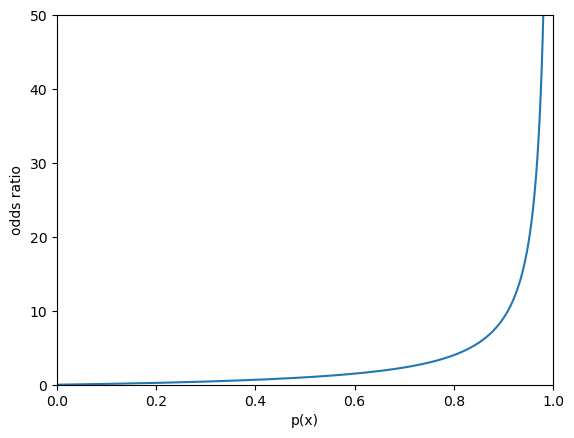

In [38]:
plt.plot(px,y)
plt.xlim([0,1])
plt.ylim([0,50])
plt.ylabel("odds ratio")
plt.xlabel("p(x)")
plt.show()

As said in the class, this function form is not ideal at all. What happens if we apply the log?

In [39]:
y=np.log(px/(1-px))

It will be clear with in plot

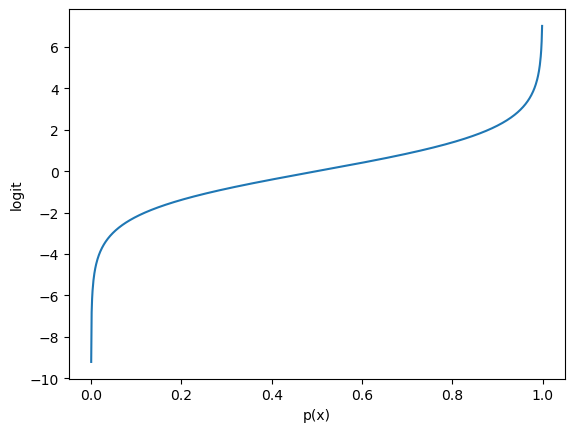

In [40]:
plt.plot(px,y)
plt.ylabel("logit")
plt.xlabel("p(x)")
plt.show()

ok, now it seems much more balanced, doesn't it? 

Understanding this function is important:
- What is the probability of x (p(x)) when the log odds ratio is 0? 
    50 %

- What is the odds ratio itself? 


- What about the extremes (when is it 1 and when is it 0?)?
    at +/- infinity

------

Let's start playing with data. First we need to load:

In [41]:
f=pd.read_csv("NYC_taxis_weather_2016_with_dummies.csv")

Take a look at the dataframe yourself

In [42]:
f.head()

,datetime,pickups1,pickups17_lag1,pickups17_lag2,pickups1_lag1,pickups1_lag2,pickups21_lag1,pickups21_lag2,pickups28_lag1,pickups28_lag2,...,fog,rain_drizzle,time_of_day_afternoon,time_of_day_afternoon rush,time_of_day_evening,time_of_day_lunch time,time_of_day_morning,time_of_day_morning rush,time_of_day_night,is_weekend
0,2016-01-01 00:00:00,162,202.0,307.0,109.0,171.0,198.0,306.0,40.0,54.0,...,0,0,0,0,0,0,0,0,1,False
1,2016-01-01 00:15:00,251,394.0,202.0,162.0,109.0,312.0,198.0,29.0,40.0,...,0,0,0,0,0,0,0,0,1,False
2,2016-01-01 00:30:00,310,420.0,394.0,251.0,162.0,699.0,312.0,16.0,29.0,...,0,0,0,0,0,0,0,0,1,False
3,2016-01-01 00:45:00,338,310.0,420.0,310.0,251.0,482.0,699.0,3.0,16.0,...,0,0,0,0,0,0,0,0,1,False
4,2016-01-01 01:00:00,369,403.0,310.0,338.0,310.0,459.0,482.0,2.0,3.0,...,0,0,0,0,0,0,0,0,1,False


It will be useful (for what we want to do later) to set the index of the dataframe to be the datetime column. Can you do this? Refer the notebook on Pandas from Week 1 and 2.

In [43]:
# Set the index to be the datetime
f=f.set_index(pd.DatetimeIndex(f.datetime))
f=f.sort_index()
f.head()

,datetime,pickups1,pickups17_lag1,pickups17_lag2,pickups1_lag1,pickups1_lag2,pickups21_lag1,pickups21_lag2,pickups28_lag1,pickups28_lag2,...,fog,rain_drizzle,time_of_day_afternoon,time_of_day_afternoon rush,time_of_day_evening,time_of_day_lunch time,time_of_day_morning,time_of_day_morning rush,time_of_day_night,is_weekend
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,2016-01-01 00:00:00,162,202.0,307.0,109.0,171.0,198.0,306.0,40.0,54.0,...,0,0,0,0,0,0,0,0,1,False
2016-01-01 00:15:00,2016-01-01 00:15:00,251,394.0,202.0,162.0,109.0,312.0,198.0,29.0,40.0,...,0,0,0,0,0,0,0,0,1,False
2016-01-01 00:30:00,2016-01-01 00:30:00,310,420.0,394.0,251.0,162.0,699.0,312.0,16.0,29.0,...,0,0,0,0,0,0,0,0,1,False
2016-01-01 00:45:00,2016-01-01 00:45:00,338,310.0,420.0,310.0,251.0,482.0,699.0,3.0,16.0,...,0,0,0,0,0,0,0,0,1,False
2016-01-01 01:00:00,2016-01-01 01:00:00,369,403.0,310.0,338.0,310.0,459.0,482.0,2.0,3.0,...,0,0,0,0,0,0,0,0,1,False


So, imagine that you are an NYC taxi fleet manager. At each 15 minutes, you goal is to make sure your company has enough cars for very big spikes in demand across the city (e.g., above the 90th percentile). If you detect some very big spike in a specific area, you coordinate with the cars in the neighbourhood to go there. 

For this exercise, let's assume that area 1 is the only truly important for you. Doing this manually would be very tiring (if at all possible), so you rely on your Data Science skills to get a model that does it for you:

**At each 15 minutes time interval, predict whether the next time interval will have a demand spike ("stress").**

Let's first find the actual value above which you call it a "stress" situation:

In [44]:
stress_threshold=np.percentile(f['pickups1'], 90)
print(stress_threshold)

# Make a binary variable for stress
f['stress']= (f['pickups1']>stress_threshold).astype(int)


324.89999999999964


How many demand pickups exist above percentile 90? And above other percentiles (e.g. percentile 50)?  

In [45]:
f['stress'].value_counts()

stress
0    15724
1     1748
Name: count, dtype: int64

Let's now create our model. The first thing to do is to import the sklearn package that has Logistic Regression, and then just create the respective object.

In [46]:
from sklearn.linear_model import LogisticRegression
LogReg=LogisticRegression()

We have a model, but it is "empty", so let's create the training and test sets now. 

We will create the model with 2/3 of the data (training set), and then 1/3 of the data is kept aside for later validation (test set).

In [47]:
split=int(len(f)*2.0/3)
training=f[:split]
test=f[split:]

We need to create the x and y for the training and test set now. Notice that the y is the "target" variable, i.e. our "stress" column, and the x comes from **almost** all other columns. Let's check all columns

In [48]:
training.columns

Index(['datetime', 'pickups1', 'pickups17_lag1', 'pickups17_lag2',
       'pickups1_lag1', 'pickups1_lag2', 'pickups21_lag1', 'pickups21_lag2',
       'pickups28_lag1', 'pickups28_lag2', 'temp', 'prcp', 'fog',
       'rain_drizzle', 'time_of_day_afternoon', 'time_of_day_afternoon rush',
       'time_of_day_evening', 'time_of_day_lunch time', 'time_of_day_morning',
       'time_of_day_morning rush', 'time_of_day_night', 'is_weekend',
       'stress'],
      dtype='object')

Ok, we need to create the x using EVERYTHING but the 'stress' variable, but also we need to remove "pickups1" (**why?**)
 - We need to remove the variables we want to predict. ie. sress and an pickups since we use it to create the stress variable

Notice also that we have several dummy variables relating to the categorical 'time of day' variable. Recall that we discussed the method of dummy variables as a way of including categorical variables as predictors in our model.  In this case, the time of day variable has seven possible values and we created seven dummy variables using the pd.get_dummies() function. In logistic regression when including dumming variables for a categorical variable that takes k values, it recommended to only include k-1 of the dummies and not all k of them. The reason for this is that these k dummy variables sum to 1 leading to multicollinearity (linear dependence), which will make it difficult to interpret the coefficients. Thus, we will arbitrarily exclude the dummy 'time_of_day_night'. It is also important to note that when interpreting the coefficients for these dummy variables you interpret them as measuring an 'effect' relative to the baseline category that you left out (in this case the remaining six dummy variables should be interpreted as measuring effects relative to the 'time_of_day_night'). FYI, in Pandas, we can automatically create k-1 dummies instead of k dummies using the option 'drop_first=False' in the pd.get_dummies() function.

The other methods for classification that we will cover (e.g., SVM, decision trees) are less sensitive to multicollinearity and there you can include all the seven dummies.

In [49]:
x_train=training[['pickups17_lag1', 'pickups17_lag2', 'pickups1_lag1',
       'pickups1_lag2', 'pickups21_lag1', 'pickups21_lag2', 'pickups28_lag1',
       'pickups28_lag2',  'temp', 'prcp','fog', 'rain_drizzle', 'is_weekend', 'time_of_day_afternoon',
       'time_of_day_afternoon rush', 'time_of_day_evening',
       'time_of_day_lunch time', 'time_of_day_morning',
       'time_of_day_morning rush']]
x_test=test[['pickups17_lag1', 'pickups17_lag2', 'pickups1_lag1',
       'pickups1_lag2', 'pickups21_lag1', 'pickups21_lag2', 'pickups28_lag1',
       'pickups28_lag2',  'temp', 'prcp','fog', 'rain_drizzle', 'is_weekend', 'time_of_day_afternoon',
       'time_of_day_afternoon rush', 'time_of_day_evening',
       'time_of_day_lunch time', 'time_of_day_morning',
       'time_of_day_morning rush']]

To make sure you understand things, don't forget to ALWAYS play with the code here... For example, what's the content of the new lists x_train and x_test?

...and now the ys are trivial

In [50]:
y_train=training['stress']

y_test=test['stress']

To make sure you understood, do you want to see what's inside these two vectors?

In [51]:
print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

(11648, 19)
(5824, 19)
(11648,)
(5824,)


Ok, we have our Xs and Ys! Ready to go... it's totally trivial with sklearn:

In [52]:
LogReg.fit(x_train, y_train)

/home/husted42/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Congrats! You trained your first Logistic Regression model. What's its accuracy (**on the test set**)?

In [53]:
LogReg.score(x_test,y_test)

0.9225618131868132

Do you want to try it on the training set? What do you expect?

In [54]:
# If the model has not overfitted we expect the training and test scores to be similar. But if we overfit the training score will be much higher than the test score.
LogReg.score(x_train,y_train)

0.9331215659340659

If the values tend to be similar, then congrats, it's very likely that your model is not overfitting! :-)



The values are very similar. So we have not overfitted, we get a better model on the traning data which was expected since it's the data that we trained on. 


Anyway, accuracy is not everything in a classifier. Another VERY interesting concept is the confusion matrix

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

To use it properly, let's first obain the predictions of our model using the test set:

In [56]:
ypred=LogReg.predict(x_test)

Now, we can compare the predictions with the observations, using the confusion matrix

In [57]:
cm = confusion_matrix(y_test, ypred)
cm

array([[5190,   46],
       [ 405,  183]])

Important: pay attention to the rows and columns in the confusion matrix. The format that Sklearn uses is different from what we had in the slides - the rows represent actual (true) values and the columns represent predicted values.
You can see the documentation here: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

Alternatively, we can also plot the confusion matrix just to be sure:

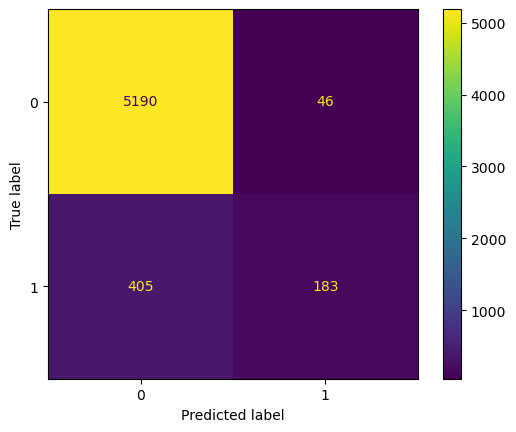

In [58]:
display = ConfusionMatrixDisplay(cm)
display.plot()
plt.show() 

Remember we mentioned that accuracy is not a good measure if the data set is imbalanced. In our problem and data set, is the response variable imbalanced? In general, a better measure to use is the f1 score. We can compute this easily:

In [59]:
from sklearn.metrics import f1_score
f1_score(y_test,ypred)

0.4479804161566707

We see that we got a good accuracy beacuase of the class imbalance. A model that mainly predict 0 would also score a high accuracy. 
 

A last useful thing about Logistic Regression. It is a parametric model, so its parameters beta (its "coefficients") can can be easily interpreted. Let's take a look at them:

In [60]:
LogReg.coef_

array([[-4.95659750e-03, -8.96932763e-04,  2.97855798e-02,
         1.65555388e-02, -5.57384831e-03, -4.35243503e-03,
        -5.43264244e-03, -7.09776661e-03, -6.36301523e-02,
        -2.89785178e-01, -6.64752176e-01,  8.05606587e-01,
        -1.86464904e+00, -1.17115930e+00,  3.02769701e+00,
         8.82931375e-01, -8.43863536e-01, -2.22701237e+00,
        -5.49926010e-01]])

This is a bit confusing. Which coefficient correspond to which variable? Let's make it more interpretable:

In [61]:
for cname, val in zip(x_train.columns, LogReg.coef_.tolist()[0]):
    print("%s=%.3f"%(cname, val))

pickups17_lag1=-0.005
pickups17_lag2=-0.001
pickups1_lag1=0.030
pickups1_lag2=0.017
pickups21_lag1=-0.006
pickups21_lag2=-0.004
pickups28_lag1=-0.005
pickups28_lag2=-0.007
temp=-0.064
prcp=-0.290
fog=-0.665
rain_drizzle=0.806
is_weekend=-1.865
time_of_day_afternoon=-1.171
time_of_day_afternoon rush=3.028
time_of_day_evening=0.883
time_of_day_lunch time=-0.844
time_of_day_morning=-2.227
time_of_day_morning rush=-0.550


What do you think of the results? Take a look at the signs. Do they make sense? Try to play with the stress_threshold above (instead of 90 percentile, you can try others...)

In [62]:
# We see that rush hours are not likely to occur in the afternoon, weekend and morning. Due to their high negative coefficients.

------

## Part 2 - Support Vector Machines


For the rest of the notebook, we will include the dummy that we left out earlier - 'time_of_day_night':

In [63]:
x_train=training[['pickups17_lag1', 'pickups17_lag2', 'pickups1_lag1',
       'pickups1_lag2', 'pickups21_lag1', 'pickups21_lag2', 'pickups28_lag1',
       'pickups28_lag2',  'temp', 'prcp','fog', 'rain_drizzle', 'is_weekend', 'time_of_day_afternoon',
       'time_of_day_afternoon rush', 'time_of_day_evening',
       'time_of_day_lunch time', 'time_of_day_morning',
       'time_of_day_morning rush','time_of_day_night']]
x_test=test[['pickups17_lag1', 'pickups17_lag2', 'pickups1_lag1',
       'pickups1_lag2', 'pickups21_lag1', 'pickups21_lag2', 'pickups28_lag1',
       'pickups28_lag2',  'temp', 'prcp','fog', 'rain_drizzle', 'is_weekend', 'time_of_day_afternoon',
       'time_of_day_afternoon rush', 'time_of_day_evening',
       'time_of_day_lunch time', 'time_of_day_morning',
       'time_of_day_morning rush','time_of_day_night']]

In Part 1, we did almost everything for you. But now, we'll just help you with the import:

You can find more details about the support vector classifiers here: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

Note that the default kernel is the rbf kernel. We encourage you to experiment with the different values of  the kernel coefficient gamma for the RBF kernel and the tolerance parameter C.

In [64]:
from sklearn.svm import SVC

Create the object

In [65]:
# Check data types of all columns
print(x_train.dtypes)

# Create a list of numerical columns based on x_train.dtypes.
num_cols = x_train.dtypes[x_train.dtypes != "object"].index.tolist()
num_cols_test = x_test.dtypes[x_test.dtypes != "object"].index.tolist()

pickups17_lag1                float64
pickups17_lag2                float64
pickups1_lag1                 float64
pickups1_lag2                 float64
pickups21_lag1                float64
pickups21_lag2                float64
pickups28_lag1                float64
pickups28_lag2                float64
temp                          float64
prcp                          float64
fog                             int64
rain_drizzle                    int64
is_weekend                       bool
time_of_day_afternoon           int64
time_of_day_afternoon rush      int64
time_of_day_evening             int64
time_of_day_lunch time          int64
time_of_day_morning             int64
time_of_day_morning rush        int64
time_of_day_night               int64
dtype: object


Remember that SVM's rely on computing 'distances' between features. Hence, it is critical that your data is standardized. Can you standardize the data first? 

In [66]:
# Normalize the numerical columns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols_test] = scaler.transform(x_test[num_cols_test])


/tmp/ipykernel_24831/3366605563.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
/tmp/ipykernel_24831/3366605563.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[num_cols_test] = scaler.transform(x_test[num_cols_test])


Train the model

In [67]:
# Train the SVM model
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(x_train, y_train)

SVC(kernel='linear', probability=True)

Check its accuracy and f1 score

In [68]:
pred_svm = svm_model.predict(x_test)
# f1-score
f1_svm = f1_score(y_test, pred_svm)
print("F1 Score for SVM:", f1_svm)


F1 Score for SVM: 0.7414965986394558


Check its confusion matrix

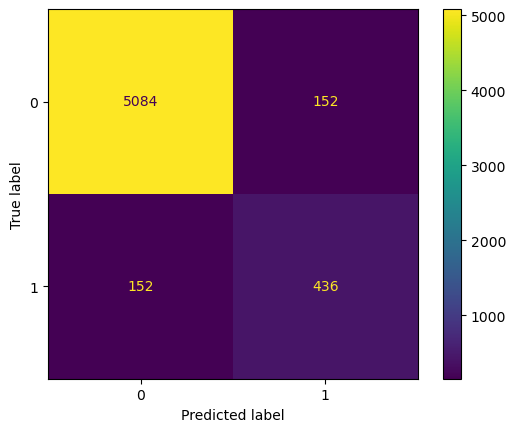

In [70]:
cm_svm = confusion_matrix(y_test, pred_svm)
display_svm = ConfusionMatrixDisplay(cm_svm)
display_svm.plot()
plt.show()

Is this model better than the Logistic regression model? Look at both the f1 score and the confusion matrix. In this case, do you care more about false positives or false negatives?